In [1]:
from pathlib import Path
import yaml
import os 
os.chdir(Path('/gpfs-calypso/home/globc/garcia/'))
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import glob
import numpy as np
import xarray as xr
from scipy import stats


from scenarIA.src.data.dataloader import get_climatology
from scenarIA.src.utils.evalutils import EvaluationPlots, compare_temporal_profiles, compare_metrics_maps, compare_metrics
from scenarIA.src.utils.datautils import dataset_xr_formatting, weighted_global_mean
from scenarIA.src.utils.settings import PREDICTIONS_DIR, DATASET_DIR, GRAPHS_DIR, CONFIG_DIR, SIMUS_COLORS_DICT

with open(CONFIG_DIR / 'plots.yaml') as file:
    config_plots = yaml.safe_load(file)

/softs/Anaconda/2024.02-1/envs/gloenv_py3.11/lib/python3.12/site-packages/pyproj/__init__.py:91: UserWarning: Valid PROJ data directory not found. Either set the path using the environmental variable PROJ_DATA (PROJ 9.1+) | PROJ_LIB (PROJ<9.1) or with `pyproj.datadir.set_data_dir`.
  warnings.warn(str(err))


## Benchmark

Same dataset, different methods

In [15]:
var_name = 'pr'
#save_dir = GRAPHS_DIR/ f'runs/MPI-ESM1-2-LR/annual/exp9' # or None
save_dir = None
pred_path = PREDICTIONS_DIR / f'MPI-ESM1-2-LR/annual/exp9'
title_base = 'MPI-ESM1-2-LR_annual_exp9_benchmarkv4'
if relative_changes :
    simus_dict = {'ssp245': {'color': 'royalblue',
                        'mean_error': [-10., 10.],
                        'values': [-40., 40.],
                        'std': [0, 600.]},
            'ssp370': {'color': 'red',
                        'mean_error': [-1, 1],
                        'values': [-2.4, 2.4],
                        'std': [0, 0.3]}}
else:
    simus_dict = {'ssp245': {'color': 'royalblue',
                            'mean_error': [-0.6, 0.6],
                            'values': [-2.4, 2.4],
                            'std': [0, 0.25]},
                'ssp370': {'color': 'red',
                            'mean_error': [-1, 1],
                            'values': [-2.4, 2.4],
                            'std': [0, 0.3]}}


# Open climatology file
clim_simu = 'piControl'
clim = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_{clim_simu}.nc').mean('member')
if clim_simu == 'piControl':  
    clim = clim.sel(time=slice('1850-01-01', '2250-12-31')).mean('time')[var_name].values
else:
    clim = clim.sel(time=slice('1994-01-01', '2014-12-31')).mean('time')[var_name].values

In [3]:
true_simu = 'ssp245'

In [16]:
mini_dict = simus_dict[true_simu]
title = title_base + f'_{true_simu}'

config_plots['pr']['lim']['mean_error'] = mini_dict['mean_error']
config_plots['pr']['lim']['values'] = mini_dict['values']
config_plots['pr']['lim']['std'] = mini_dict['std']
#if relative_changes:
    #config_plots['pr']['unit'] = '%' 

color = mini_dict['color']

# Open true projection file
true = xr.open_dataset( DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_{true_simu}.nc').mean('member') # 50 members
lats = true.lat.values
t = true.time.values
y = true[var_name].values

# Open prediction files to compare
y_hat_dict = {'CNN-LSTM': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_cnn-lstm_seq5_mem30_epoch100_bs4_clim.nc')['pr'].values,
        'CNN-GRU': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_cnn-gru_seq5_mem30_epoch100_bs4_clim.nc')['pr'].values,
        'ConvLSTM': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_convlstm_seq5_mem30_epoch100_bs4_clim.nc')['pr'].values,
        'ConvGRU': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_convgru_seq5_mem30_epoch100_bs4_clim.nc')['pr'].values,
        'TrajGRU': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_trajgru_seq5_mem30_epoch100_bs4_clim.nc')['pr'].values,
        'UNet': xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_unet_seq5_mem30_epoch100_bs4_clim.nc')['pr'].values,
        'Attention-UNet' : xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_attention-unet_seq5_mem30_epoch100_bs4_clim_64.nc')['pr'].values,
        'Pattern-Scaling' : xr.open_dataset(pred_path / f'MPI-ESM1-2-LR_annual_exp9_{true_simu}_pr_pattern-scaling_seq1_mem30.nc')['pr'].values}



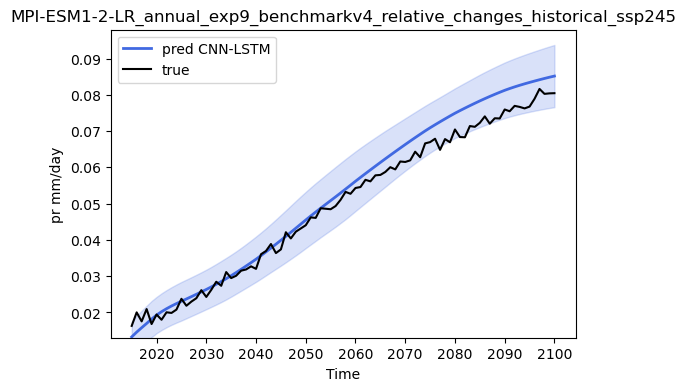

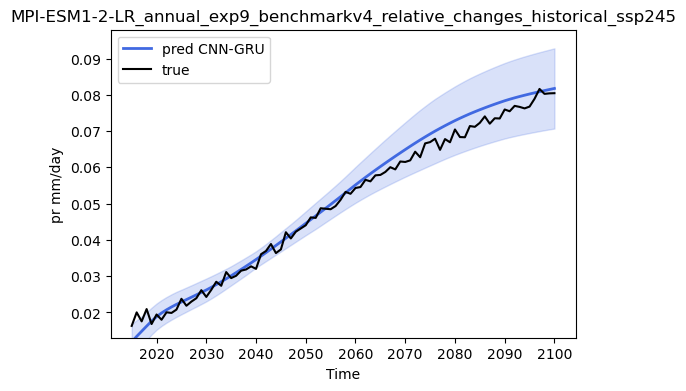

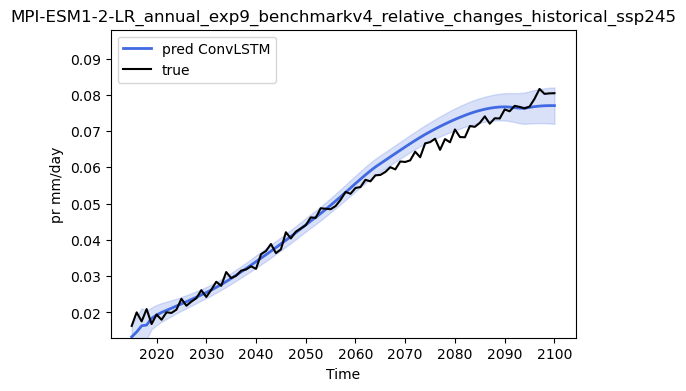

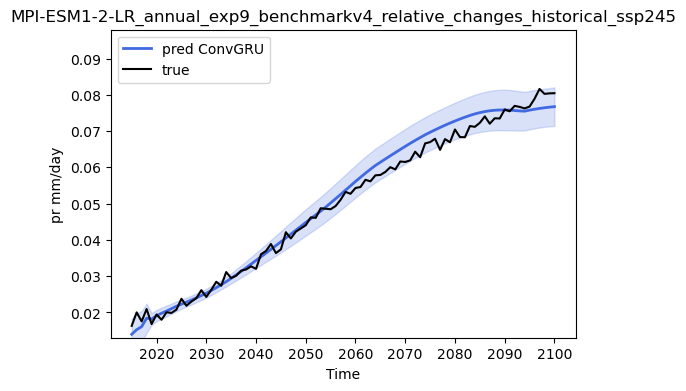

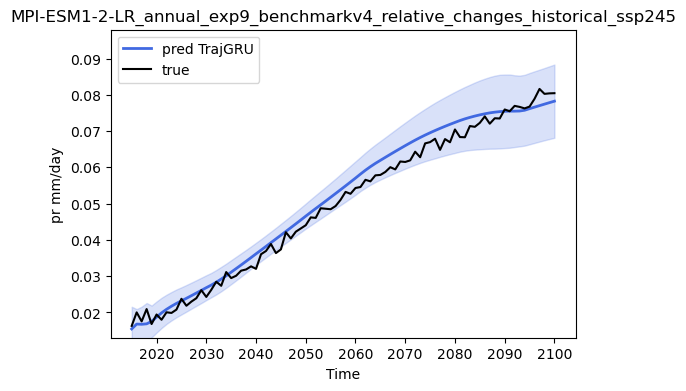

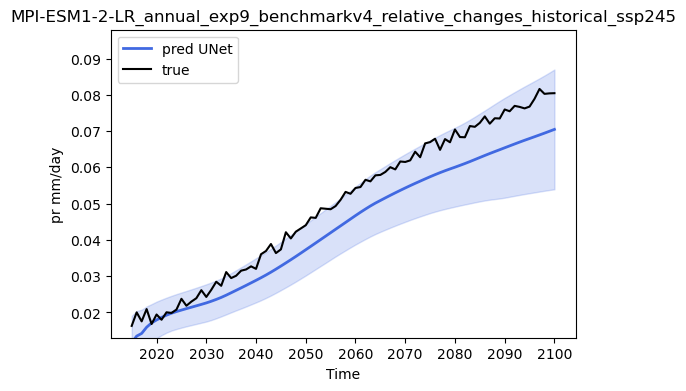

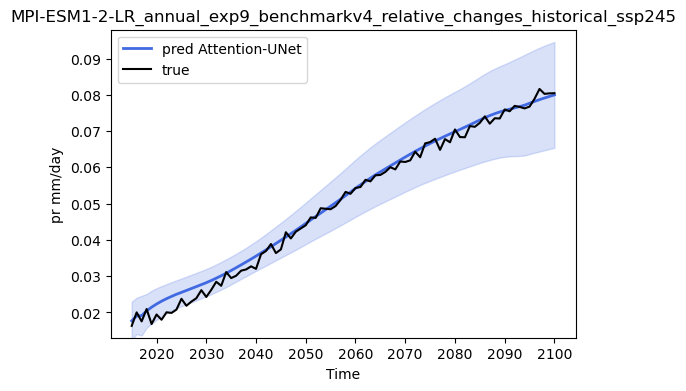

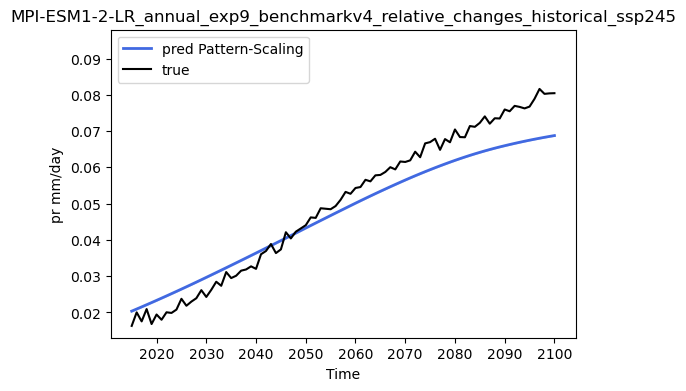

In [12]:
# clim changes 
for key, value in y_hat_dict.items():
    value = value - clim # raw changes
    test_dict = {key:value}
    color_dict = {key: color}
    compare_temporal_profiles(y - clim, # raw changes
                              test_dict, 
                              t, 
                              var_name, 
                              lats, 
                              point=None, 
                              window_size=None, 
                              config_plots=config_plots, 
                              colors=color_dict, 
                              title=title, 
                              save_dir=save_dir)

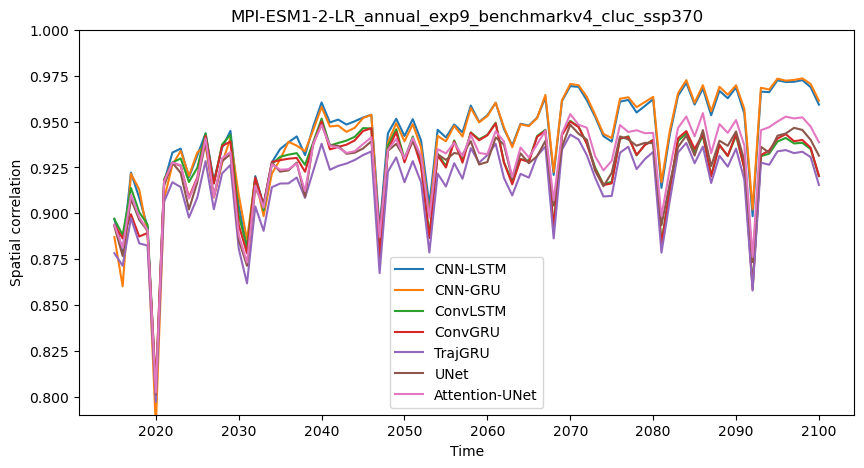

In [16]:
# Figure : Correlation spatiale

fig, ax1 = plt.subplots(figsize = (10,5))
for key, value in y_hat_dict.items():
    data = np.stack(value, axis=0)
    corr_list = []
    for run in range(data.shape[0]):
        data_seed = data[run]
        corr = [stats.pearsonr(y[i].flatten(), data_seed[i, ...].flatten()).statistic for i in range(y.shape[0])]
        corr_list.append(corr)
    corr_mean = np.stack(corr_list,axis=0).mean(axis=0)
    ax1.plot(t, corr_mean, label=key)
    ax1.set_title(title)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Spatial correlation')
    ax1.set_ylim(None,1)
ax1.legend()
if save_dir:
    fig.savefig(save_dir/f'{title}_spatial_correlation.png')

[-40. -32. -24. -16.  -8.   0.   8.  16.  24.  32.  40.]
[  0.  60. 120. 180. 240. 300. 360. 420. 480. 540. 600.]
[-10.          -7.77777778  -5.55555556  -3.33333333  -1.11111111
   1.11111111   3.33333333   5.55555556   7.77777778  10.        ]
[-1.         -0.77777778 -0.55555556 -0.33333333 -0.11111111  0.11111111
  0.33333333  0.55555556  0.77777778  1.        ]
[-40. -32. -24. -16.  -8.   0.   8.  16.  24.  32.  40.]
[  0.  60. 120. 180. 240. 300. 360. 420. 480. 540. 600.]
[-10.          -7.77777778  -5.55555556  -3.33333333  -1.11111111
   1.11111111   3.33333333   5.55555556   7.77777778  10.        ]
[-1.         -0.77777778 -0.55555556 -0.33333333 -0.11111111  0.11111111
  0.33333333  0.55555556  0.77777778  1.        ]
[-40. -32. -24. -16.  -8.   0.   8.  16.  24.  32.  40.]
[  0.  60. 120. 180. 240. 300. 360. 420. 480. 540. 600.]
[-10.          -7.77777778  -5.55555556  -3.33333333  -1.11111111
   1.11111111   3.33333333   5.55555556   7.77777778  10.        ]
[-1.         

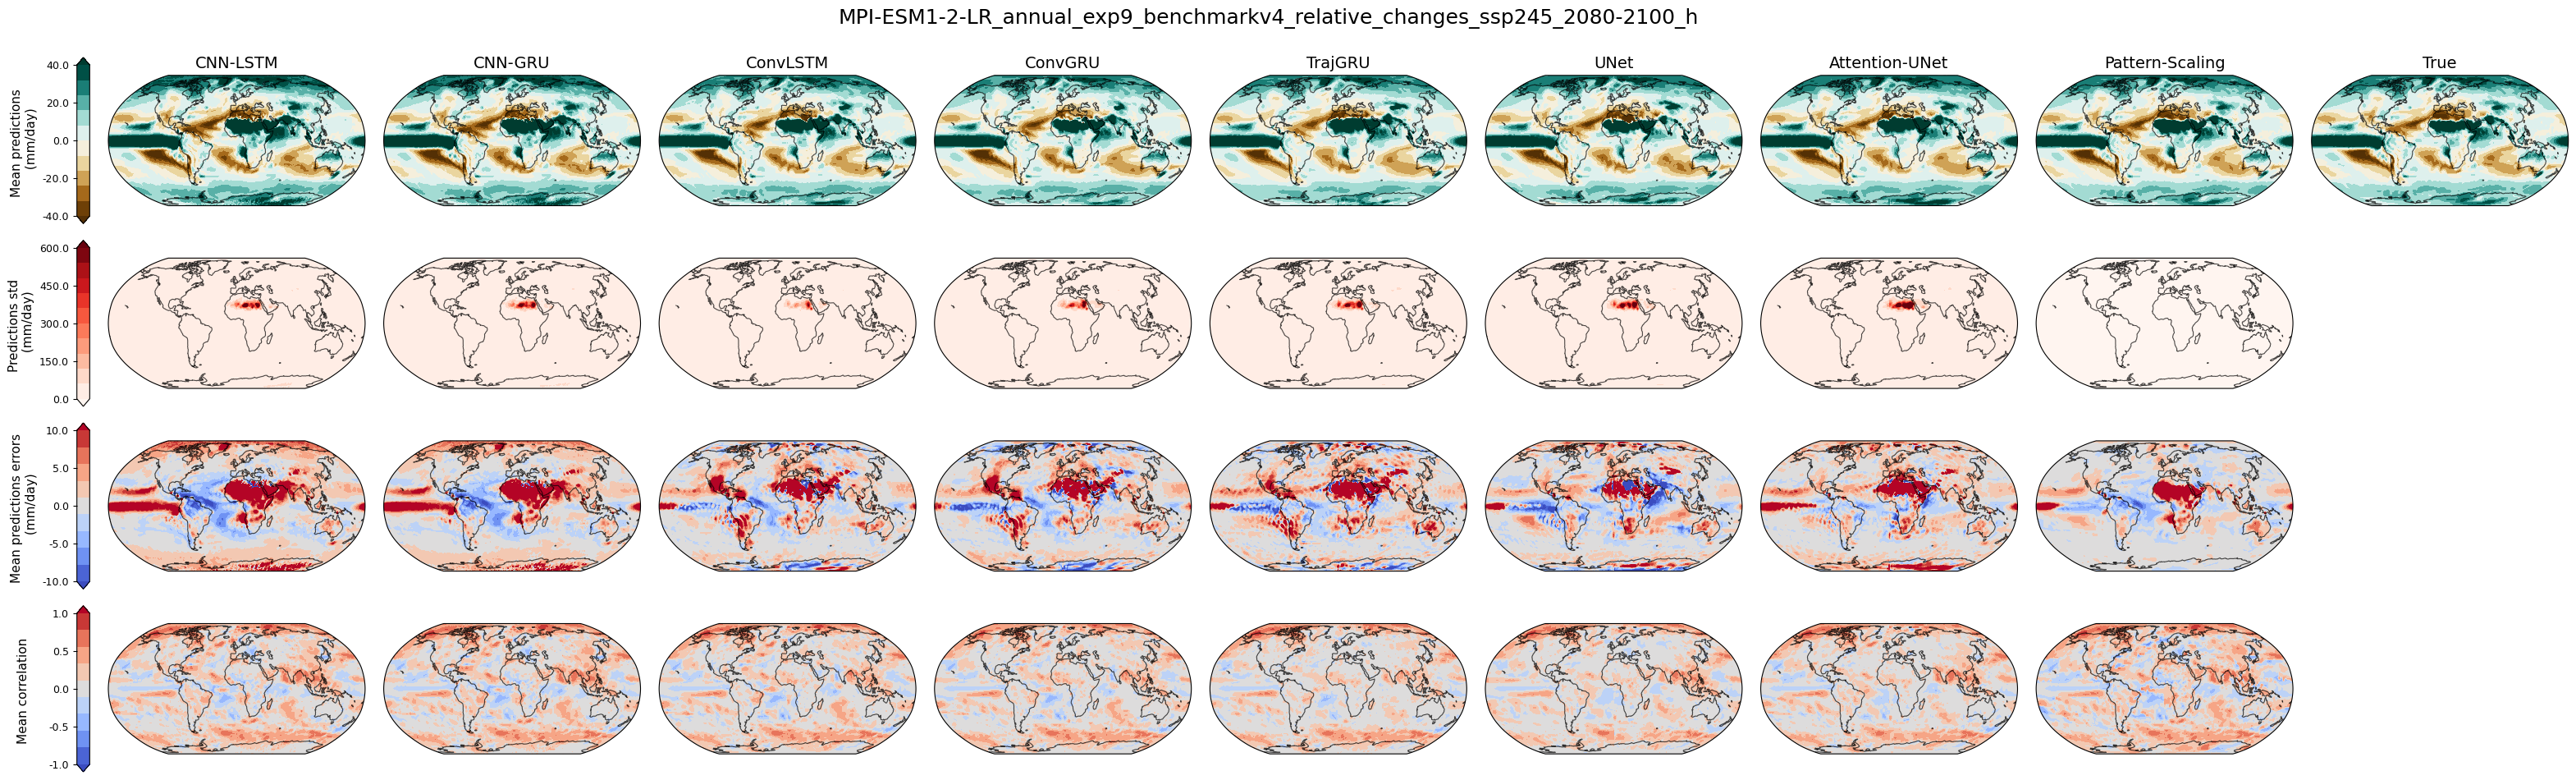

In [17]:
y_end = y[-21:, :, :]

for key, y_hat in y_hat_dict.items():
    y_hat_dict[key] = [i[-21:,:,:] for i in y_hat]
compare_metrics_maps(y_end, 
                    y_hat_dict, 
                    var_name=var_name, 
                    title=f'{title}_2080-2100_h', 
                    save_dir=save_dir,
                    config_plots=config_plots,
                    no_limits=False,
                    climatology=clim,
                    relative_changes=True)

/gpfs-calypso/home/globc/garcia/scenarIA/src/utils/evalutils.py:656: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  metrics_values_mean  = [torch.tensor(metric_dict[metric][t]).mean().item()             for t in test_names]
/gpfs-calypso/home/globc/garcia/scenarIA/src/utils/evalutils.py:657: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  metrics_values_lower = [torch.tensor(metric_dict[metric][t]).quantile(0.025).item()    for t in test_names]
/gpfs-calypso/home/globc/garcia/scenarIA/src/utils/evalutils.py:658: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(

['CNN-LSTM', 'CNN-GRU', 'ConvLSTM', 'ConvGRU', 'TrajGRU', 'UNet', 'Attention-UNet', 'Pattern-Scaling'] = [1.9318697327854317, 1.7956962117759177, 1.620046415723514, 1.656543028226554, 1.7376084418942626, 2.0402882677230756, 1.5331066775595021, 1.6910178504240252] with 95% CI [[1.454377078151045, 1.3995215730269355, 1.4939636110671872, 1.5231762667647128, 1.45826701895201, 1.5888586050963773, 1.1704108554216954, 1.6910178504240252], [2.627239519018627, 2.3631790708859195, 1.7437907859223158, 1.8742004187623926, 2.126247308598688, 2.6850197397802154, 2.179107119875096, 1.6910178504240252]]


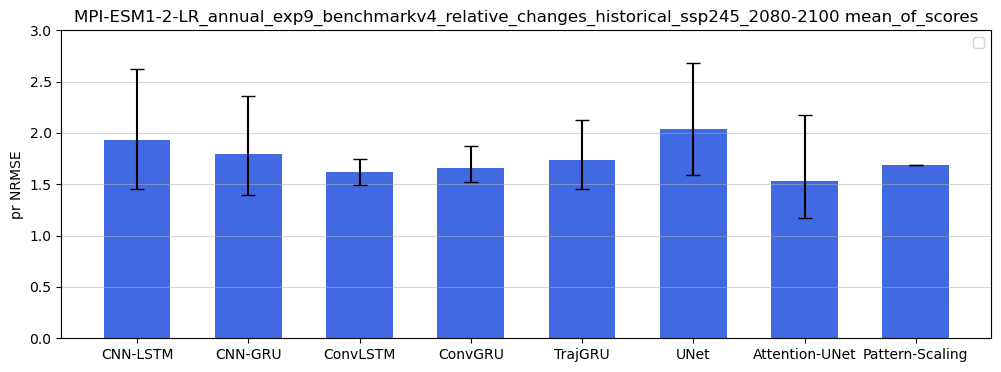

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['CNN-LSTM', 'CNN-GRU', 'ConvLSTM', 'ConvGRU', 'TrajGRU', 'UNet', 'Attention-UNet', 'Pattern-Scaling'] = [1.5226612263884942, 1.4440425499275098, 1.37428879295905, 1.3937150164902765, 1.4197587123480815, 1.364768716382312, 1.188130494313752, 1.0604891073445695] with 95% CI [[1.2568132584341334, 1.2679625553944927, 1.3031832335492768, 1.3241269450188833, 1.2867279847471251, 1.1933047513636108, 1.0321860218442718, 1.0604891073445695], [1.7968835181691762, 1.6882647691946566, 1.4920675658387077, 1.5181248857473366, 1.637402065302111, 1.519105736366279, 1.3020636850141603, 1.0604891073445695]]


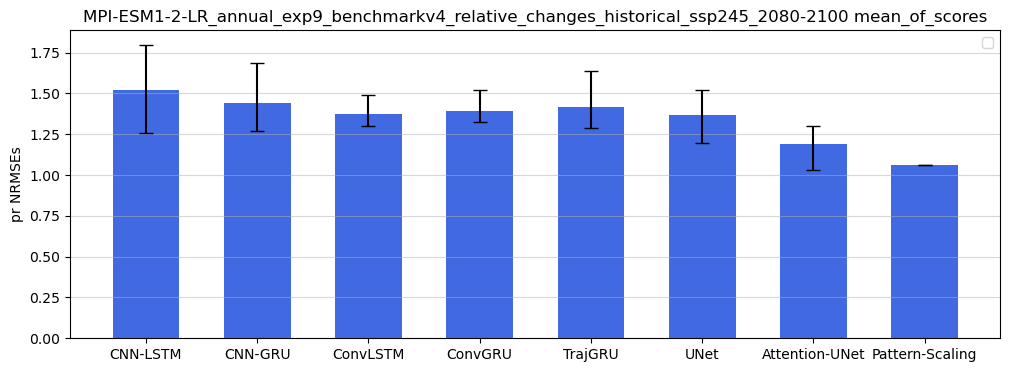

['CNN-LSTM', 'CNN-GRU', 'ConvLSTM', 'ConvGRU', 'TrajGRU', 'UNet', 'Attention-UNet', 'Pattern-Scaling'] = [0.08184170127938754, 0.07033073236968154, 0.049151524552892775, 0.05256560234725559, 0.0635699459092363, 0.13510391026815272, 0.06899523664915, 0.12610574861589113] with 95% CI [[0.025853251011141797, 0.02406675697301312, 0.03501687452438026, 0.03878845284248808, 0.026221275490315228, 0.029159466299991978, 0.02368173867037123, 0.12610574861589113], [0.17423711455724178, 0.14012726993679642, 0.06611098972628505, 0.07889570800100093, 0.1360133883257815, 0.28191698693517003, 0.18208755340223337, 0.12610574861589113]]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


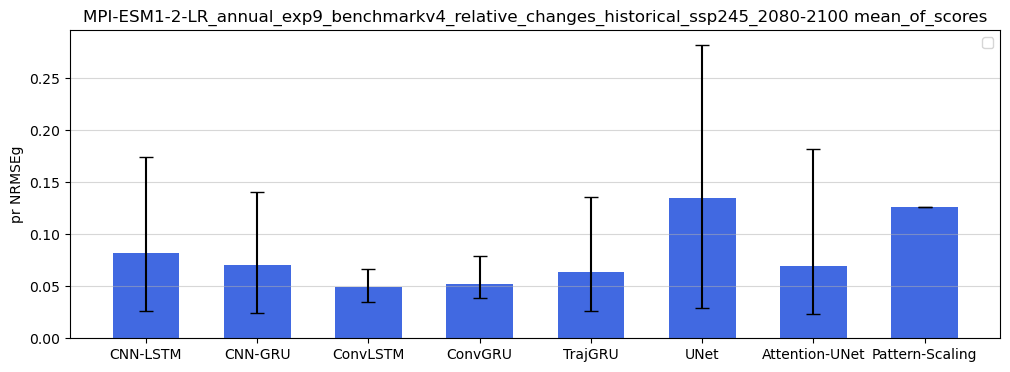

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['CNN-LSTM', 'CNN-GRU', 'ConvLSTM', 'ConvGRU', 'TrajGRU', 'UNet', 'Attention-UNet', 'Pattern-Scaling'] = [0.11417632809018272, 0.10828112852637968, 0.10305066248237091, 0.10450733244481247, 0.10646021172709019, 0.10233680219103913, 0.08909163429246367, 0.07952048043111155] with 95% CI [[0.09424179223596704, 0.09507781916412371, 0.09771883190869685, 0.09928929028166772, 0.09648493965907527, 0.08947962451662458, 0.07739818144559711, 0.07952048043111155], [0.13473881028476417, 0.12659406363676898, 0.11188227097237124, 0.1138361718503065, 0.12278013794762335, 0.11390972066085936, 0.0976348828735188, 0.07952048043111155]]


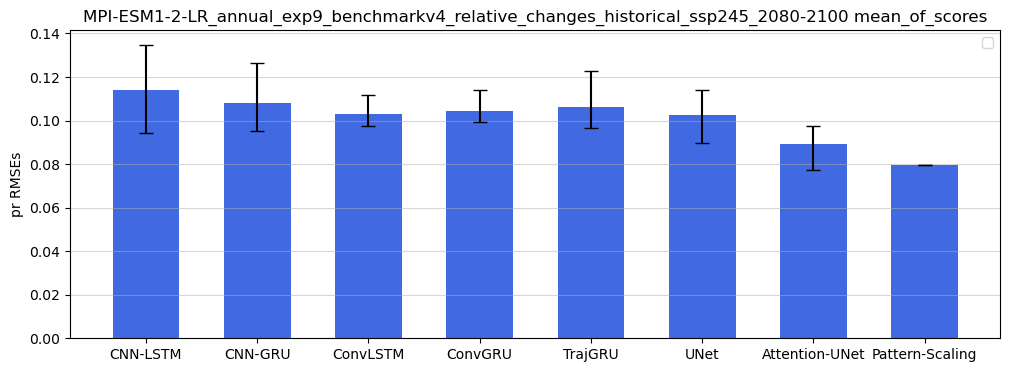

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['CNN-LSTM', 'CNN-GRU', 'ConvLSTM', 'ConvGRU', 'TrajGRU', 'UNet', 'Attention-UNet', 'Pattern-Scaling'] = [0.006136877182390364, 0.005273730383816041, 0.0036856133828234217, 0.003941617055616178, 0.0047667746935563405, 0.010130729093056633, 0.005173588609068082, 0.00945600444701446] with 95% CI [[0.0019385988284782395, 0.00180463907046146, 0.002625730586094481, 0.00290854133611763, 0.001966195041576138, 0.002186514461328421, 0.0017757685802425483, 0.00945600444701446], [0.013065121520404873, 0.010507404319103087, 0.0049573141566482196, 0.005915972696694397, 0.0101989260519724, 0.021139466768225944, 0.013653784491316422, 0.00945600444701446]]


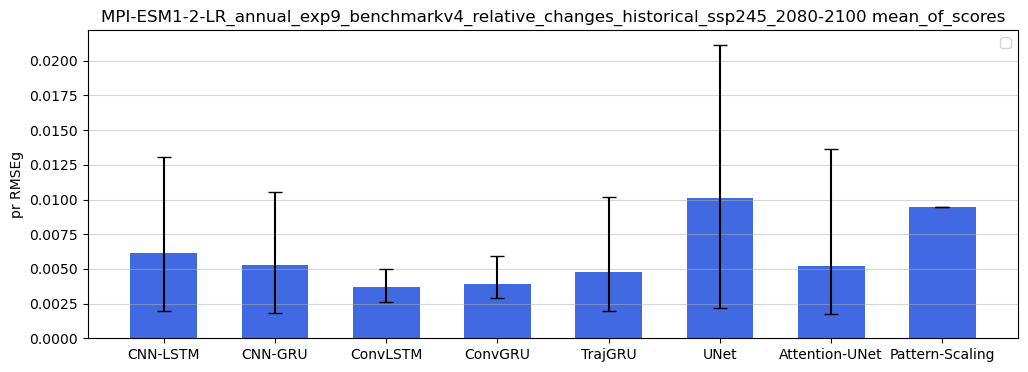

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['CNN-LSTM', 'CNN-GRU', 'ConvLSTM', 'ConvGRU', 'TrajGRU', 'UNet', 'Attention-UNet', 'Pattern-Scaling'] = [0.9391603469848633, 0.9403030276298523, 0.9300855398178101, 0.9288150668144226, 0.926383376121521, 0.9348756670951843, 0.9415497779846191, 0.9496927857398987] with 95% CI [[0.9321492314338684, 0.933213472366333, 0.9221010804176331, 0.921508252620697, 0.9121078252792358, 0.9292160272598267, 0.9366193413734436, 0.9496927857398987], [0.9456853270530701, 0.9459994435310364, 0.9339979887008667, 0.9329870939254761, 0.9353334307670593, 0.9446409344673157, 0.9484953284263611, 0.9496927857398987]]


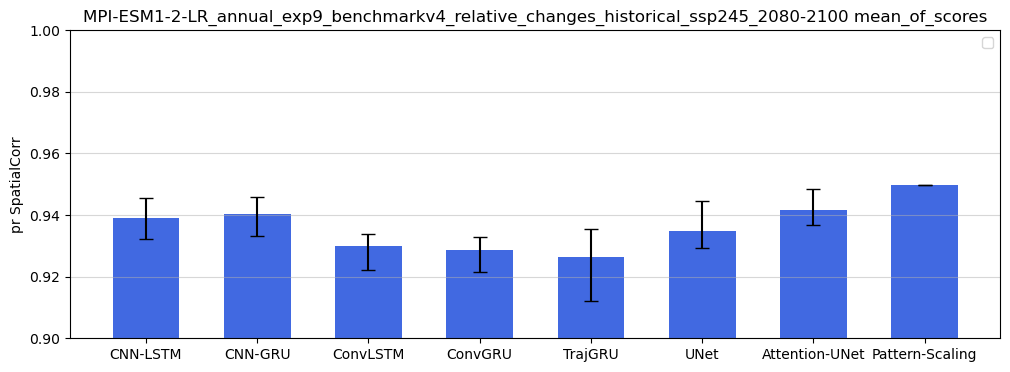

In [13]:
y_end = y[-21:, :, :] - clim # raw changes
for key, y_hat in y_hat_dict.items():
    y_hat = y_hat - clim # raw changes
    y_hat_dict[key] = [i[-21:,:,:] for i in y_hat]
compare_metrics(y_end, 
            y_hat_dict, 
            lats=lats, 
            var_name=var_name, 
            title=f'{title}_2080-2100', 
            save_dir=save_dir, 
            ensemble_scoring='mean_of_scores',
            figsize=(12,4),
            colors=color ,
            labels=None)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['CNN-LSTM', 'CNN-GRU', 'ConvLSTM', 'ConvGRU', 'TrajGRU', 'UNet', 'Attention-UNet', 'Pattern-Scaling'] = [1.8199356697183593, 1.543496625227556, 1.406722670814514, 1.3988433587472784, 1.3816358626191458, 1.809538534415329, 1.1670727777489722, 1.6910179075985219] with 95% CI [[1.592582939950057, 1.3573265183431715, 1.369710604812322, 1.3501419769013723, 1.307519963377629, 1.6139231951664401, 1.077854373164182, 1.6910179075985219], [2.069124146832715, 1.827777368487732, 1.4540298325563772, 1.4791751444791312, 1.4997655102450957, 2.0432232228599667, 1.3305700042912392, 1.6910179075985219]]
['CNN-LSTM', 'CNN-GRU', 'ConvLSTM', 'ConvGRU', 'TrajGRU', 'UNet', 'Attention-UNet', 'Pattern-Scaling'] = [1.4251605184707878, 1.3141695853784954, 1.1882058618031763, 1.185664011025051, 1.1862884863619856, 1.1559577942977206, 1.0200003155072959, 1.0604891247441712] with 95% CI [[1.3030124946656036, 1.2377520139239557, 1.1626721476651165, 1.146665389133972, 1.1367159527131203, 1.0803242202841656, 0.982356

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['CNN-LSTM', 'CNN-GRU', 'ConvLSTM', 'ConvGRU', 'TrajGRU', 'UNet', 'Attention-UNet', 'Pattern-Scaling'] = [0.07895503024951424, 0.045865407969812116, 0.04370336180226757, 0.04263586954444553, 0.03906947525143203, 0.13071614802352213, 0.02941449244833523, 0.12610575657087014] with 95% CI [[0.052278689741618076, 0.022478835737164492, 0.03931014988433962, 0.038826695081042875, 0.031057289989364908, 0.07891304998569992, 0.016111692159167103, 0.12610575657087014], [0.10884406479451071, 0.08420824787459867, 0.04906633962721284, 0.04973862912351682, 0.057942300905743975, 0.18937539070035744, 0.058566807767455896, 0.12610575657087014]]
['CNN-LSTM', 'CNN-GRU', 'ConvLSTM', 'ConvGRU', 'TrajGRU', 'UNet', 'Attention-UNet', 'Pattern-Scaling'] = [0.10686526465511971, 0.09854264044156548, 0.0890972857026728, 0.08890668572982925, 0.08895351183909009, 0.08667917333994432, 0.07648443964891319, 0.07952048173581586] with 95% CI [[0.09770602910104523, 0.09281249012379388, 0.08718264725765058, 0.0859823849261

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['CNN-LSTM', 'CNN-GRU', 'ConvLSTM', 'ConvGRU', 'TrajGRU', 'UNet', 'Attention-UNet', 'Pattern-Scaling'] = [0.9435367584228516, 0.9458466172218323, 0.9409008622169495, 0.9411020278930664, 0.9413045048713684, 0.945609450340271, 0.9491545557975769, 0.9496927857398987] with 95% CI [[0.9405413866043091, 0.9438860416412354, 0.9387131929397583, 0.9380294680595398, 0.9373072981834412, 0.9418440461158752, 0.9470241665840149, 0.9496927857398987], [0.9458734393119812, 0.9471567273139954, 0.9423292875289917, 0.9430981278419495, 0.9440377950668335, 0.9488039612770081, 0.950758695602417, 0.9496927857398987]]


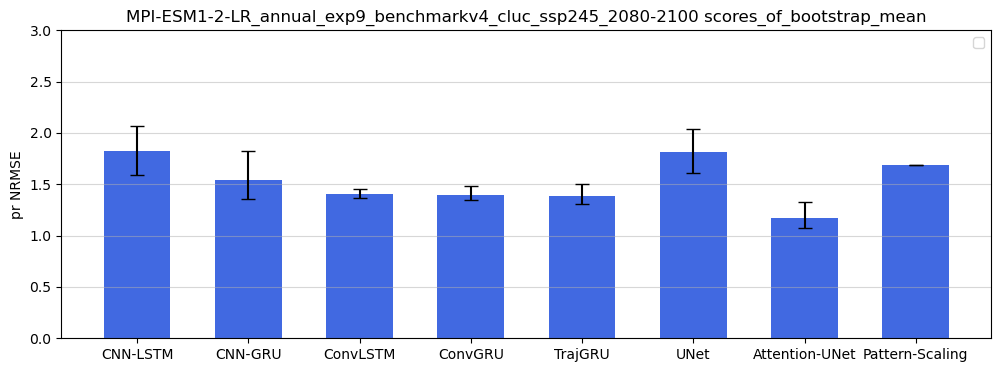

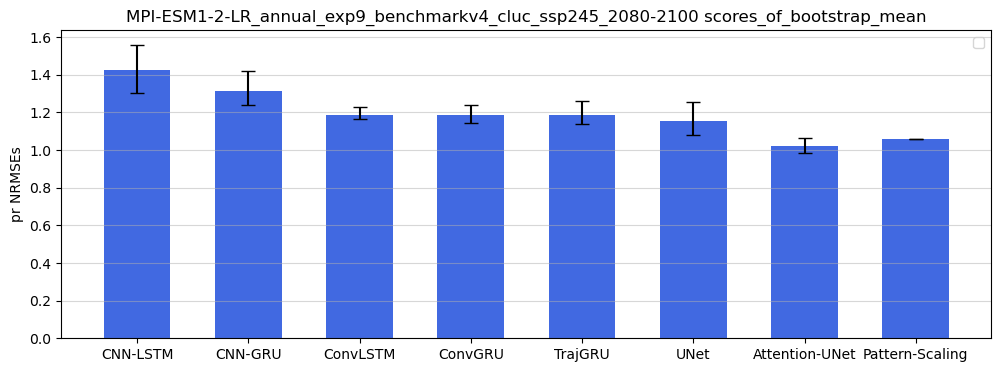

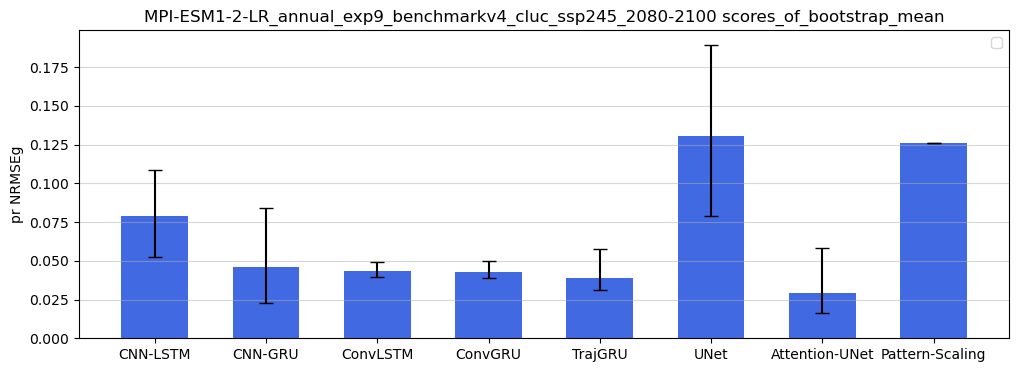

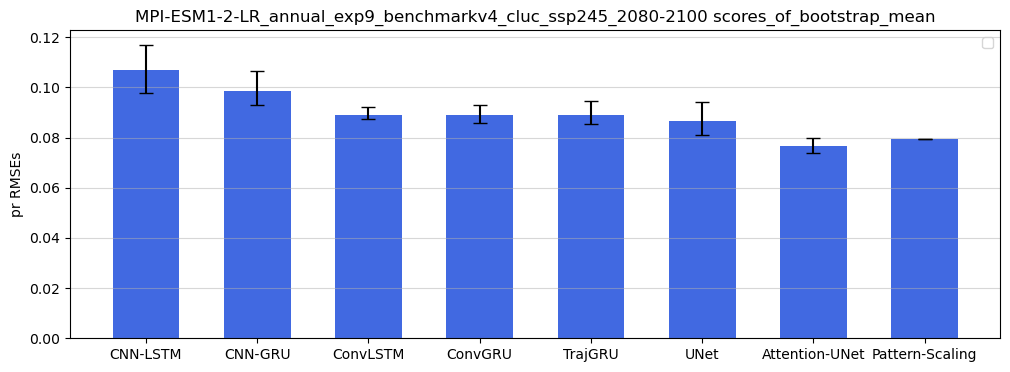

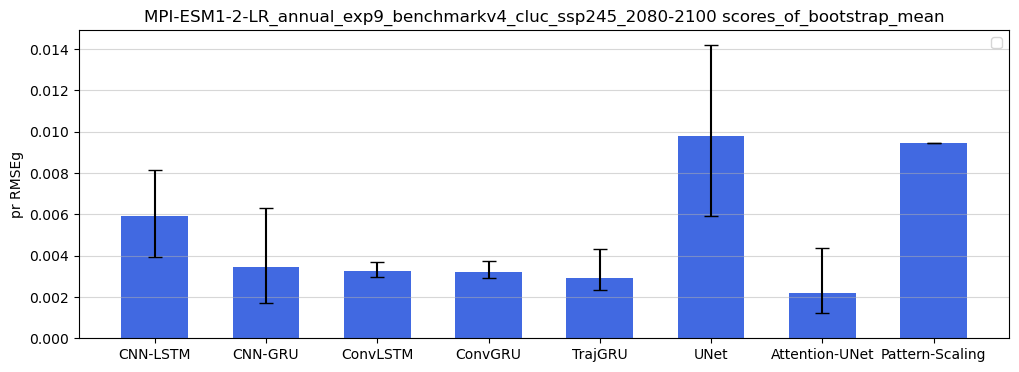

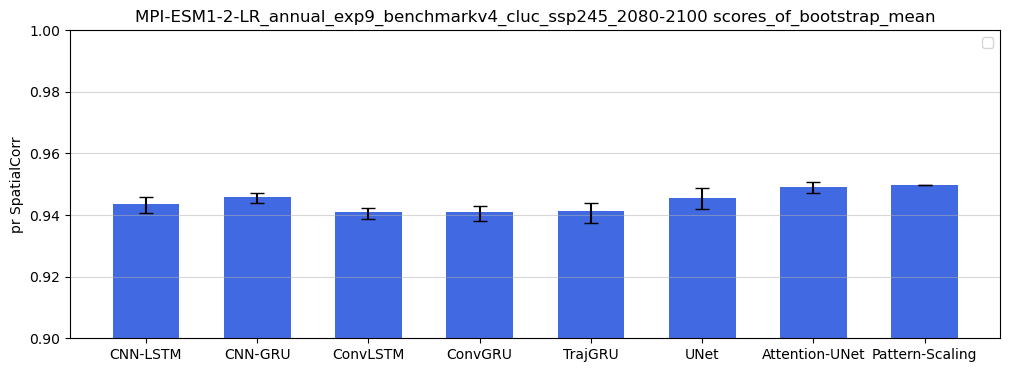

In [7]:
y_end = y[-21:, :, :]
for key, y_hat in y_hat_dict.items():
    y_hat_dict[key] = [i[-21:,:,:] for i in y_hat]
compare_metrics(y_end, 
            y_hat_dict, 
            lats=lats, 
            var_name=var_name, 
            title=f'{title}_2080-2100', 
            save_dir=save_dir, 
            ensemble_scoring='scores_of_bootstrap_mean',
            figsize=(12,4),
            colors=color ,
            labels=None)